# Part 4: Pre-Modelling Preprocessing & Feature Engineering

In this section, we will cyclically encode `Month` and `DayOfWeek` so that we can accurately represent the 12 months and 7 days of the week. By using sine and cosine, we can numerically assert that December is close to January (despite being 12 and 1) and Sunday is close to Monday (despite being 6 and 0).

In [ ]:
# Imports for Parts 4 and 5
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
import math


In [ ]:
model_df = final_cleaned_df.copy()

In [ ]:
# Define cyclical transforms for Month and DayOfWeek
def cycle_transform(value: int, day:bool = True, sin:bool = True) -> float:
  """ Applies a Sin or Cos transformation to the column to encode
  cyclicity."""

  if day and sin:
    return math.sin(2 * math.pi * value / 31)
  elif day and not sin:
    return math.cos(2 * math.pi * value / 31)
  elif not day and sin:
    return math.sin(2 * math.pi * value / 12)
  else:
    return math.cos(2 * math.pi * value / 12)

# Transform Month and DayOfWeek columns
model_df["SinMonth"] = model_df["Month"].apply(lambda x: cycle_transform(value = x, day = False, sin = True))
model_df["CosMonth"] = model_df["Month"].apply(lambda x: cycle_transform(value = x, day = False, sin = False))

model_df["SinDay"] = model_df["DayOfWeek"].apply(lambda x: cycle_transform(value = x, day = True, sin = True))
model_df["CosDay"] = model_df["DayOfWeek"].apply(lambda x: cycle_transform(value = x, day = True, sin = False))

Now, we will drop redundant or unusable columns before defining the list of columns we will need to construct our ML pipelines in part 5. By defining which columns need which type of encoding here, we are able to easily repeat code to test different ML models with mostly the same pipeline.

In [ ]:
# Drop redundant/unusable columns before encoding
cols_to_drop = ["FlightDate", "Dest", "ArrDelay", "Month", "DayOfWeek", "origin_latitude", "origin_longitude"]
model_df = model_df.drop(columns = cols_to_drop)

# Create list of columns that require One Hot Encoding
oh_encoding_cols = ["Year", "Season", "CRSArr_TimeOfDay", "CRSDep_TimeOfDay"]

# Create list of columns that require Target Encoding
target_encoding_cols = ["Origin", "dest_weather_code", "origin_weather_code", "airline_name"]

# Define target variable and numeric columns that do not need encoding
target = "IsDelayed"

numeric_cols = ["CRSElapsedTime", "AirTime", "Distance", "dest_temperature_2m_mean", "dest_wind_speed_10m_max",
                "dest_wind_gusts_10m_max", "dest_precipitation_sum", "dest_rain_sum", "dest_snowfall_sum",
                "dest_precipitation_hours", "dest_temperature_2m_range", "origin_temperature_2m_mean",
                "origin_wind_speed_10m_max", "origin_wind_gusts_10m_max", "origin_precipitation_sum",
                "origin_rain_sum", "origin_snowfall_sum", "origin_precipitation_hours", "origin_temperature_2m_range",
                "SinMonth", "CosMonth", "SinDay", "CosDay"]


In order to properly evaluate our models, we will split out data into a training and testing set. We will use our training set to fit our models and then evaluate how well they generalize by predicting on the test set. Because we have such a high volume of data, we allocated 30% of our data to the testing set and decided to train our model on the remaining 70%.


Also, since we have removed all autoregressive features from the data, we are treating this as a classical machine learning problem and are randomly splitting our data rather than preserving its original temporal order.

Finally, we also made sure to stratify our samples to ensure that the class ratios remained consistent across our training and testing samples.

In [ ]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(model_df.drop(columns = [target]),
                                                    model_df[target], test_size = 0.30,
                                                    random_state = SEED, stratify = model_df[target])

print(f"Training features df shape: {X_train.shape[0]} rows and {X_train.shape[1]} columns.")
print(f"Testing features df shape: {X_test.shape[0]} rows and {X_test.shape[1]} columns.")

Training features df shape: 332761 rows and 32 columns.
Testing features df shape: 142613 rows and 32 columns.


# Part 5: Modeling
In this section, we will explore a variety of approaches to generating predictions on whether a particular flight will or will not arrive to PHL 15 or more minutes late.

## 5.1 Baseline Model: Weighted Logistic Regression

The first model we will try is a simple baseline model. We will run a class weighted logistic regression model with sensible defaults to see if a basic predictor can do a good job of predicting flight delays. Based on the scikit learn documentation, the newton-cholesky optimizer can work well when `n_samples >> n_features * n_classes`. In our case we have 332,761 training samples, 32 features, and 2 classes. It seems like newton-cholesky could be a potential hyperparameter tweak if the regular lbfgs doesn't perform well.

Before running the logistic regression, we will use the list of columns we defined above to construct a preprocessing pipeline. This pipeline will do the following:

1. Fit_transform the StandardScaler() on all numeric features (to ensure L2 regularization works properly)
2. Generate One Hot encoded columns for all low-cardinality categorical features.
3. Generate Target Encodings for airports, airlines, and weather codes.

We will utilize scikit-learn's `ColumnTransformer` and `Pipeline` tool to orchestrate our preprocessing steps.We will also use a custom function to evaluate our models. Because we are most concerned with predicting delayed flights, we will focus on optimizing for **recall** (minimizing False Negatives). Our goal is to predict as many delayed flights correctly as we can, even at the expense of a few false alarms. This ensures that PHL isn't blindsided by a late flight, and the price of a false alarm is relatively low.

In [ ]:
# Define a function to evaluate the pipeline
def evaluate_model(pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series,
                   X_test: pd.DataFrame, y_test: pd.Series) -> dict:
  # Predictions
  y_train_pred = pipeline.predict(X_train)
  y_test_pred = pipeline.predict(X_test)

  y_train_prob = pipeline.predict_proba(X_train)[:,1]
  y_test_prob = pipeline.predict_proba(X_test)[:,1]

  # Metrics
  metrics = {}

  # Train metrics
  metrics["train_accuracy"] = accuracy_score(y_train, y_train_pred)
  metrics["train_recall"] = recall_score(y_train, y_train_pred)
  metrics["train_precision"] = precision_score(y_train, y_train_pred)
  metrics["train_f1"] = f1_score(y_train, y_train_pred)
  metrics["train_roc_auc"] = roc_auc_score(y_train, y_train_prob)

  # Test metrics
  metrics["test_accuracy"] = accuracy_score(y_test, y_test_pred)
  metrics["test_recall"] = recall_score(y_test, y_test_pred)
  metrics["test_precision"] = precision_score(y_test, y_test_pred)
  metrics["test_f1"] = f1_score(y_test, y_test_pred)
  metrics["test_roc_auc"] = roc_auc_score(y_test, y_test_prob)

  return metrics


In [ ]:
# Set up preprocessing
lrg_preprocessor = ColumnTransformer(
    transformers = [
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ]
)

# Build pipeline
lrg_pipeline = Pipeline([
    ("preprocessor", lrg_preprocessor),
    ("weighted_lrg", LogisticRegression(
        max_iter = 2000,
        class_weight = "balanced"
    ))
])

# Fit to X_train and y_train
lrg_pipeline.fit(X_train, y_train)

weighted_lrg_baseline_metrics = evaluate_model(lrg_pipeline, X_train, y_train, X_test, y_test)


In [ ]:
# View metrics
pd.Series(weighted_lrg_baseline_metrics).round(4)

train_accuracy     0.6527
train_recall       0.6678
train_precision    0.3111
train_f1           0.4245
train_roc_auc      0.7121
test_accuracy      0.6528
test_recall        0.6644
test_precision     0.3105
test_f1            0.4232
test_roc_auc       0.7133
dtype: float64

In [ ]:
lrg_preproc = lrg_pipeline.named_steps["preprocessor"]
lrg_model = lrg_pipeline.named_steps["weighted_lrg"]

feature_names = lrg_preproc.get_feature_names_out()
coefs = lrg_model.coef_.flatten()


coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

coef_df.head(10)

,feature,coef,abs_coef
40,te__airline_name,5.253367,5.253367
37,te__Origin,2.678554,2.678554
1,scale_numeric__AirTime,2.043600,2.043600
0,scale_numeric__CRSElapsedTime,-1.864321,1.864321
27,ohe__Year_2025,1.050188,1.050188
26,ohe__Year_2024,0.921529,0.921529
25,ohe__Year_2023,0.786943,0.786943
24,ohe__Year_2022,0.752466,0.752466
23,ohe__Year_2021,0.544442,0.544442
29,ohe__Season_Summer,0.476683,0.476683


We see that airline name, airport, airtime, and schedule elapsed time are the most important factors in predicting delyas. We also see some strong year and seasonal effects. This could indicate that recent years have been particular novel or that summer is particularly busy for PHL.

The model did relatively ok on recall but fell short on precision. However, even though the model isn't overfitting, it is not particularly powerful either. A 66% test recall rate indicates that our model catches 66% of all delayed flights. Missing 30% of all delayed flights is not operationally acceptable and so this model wouldn't be useful in practice. However, it is a good starting point for further exploration. Since we did not find any strong linear correlations in our EDA, we suspect that the relationship between our target and features is highly non-linear. So, we will explore 2 non parametric models: **Random Forest classifiers** and **XG Boost classifiers** to see if they can better capture the nuances of flight delays.

## 5.2 Random Forest
Our baseline model did relatively ok in terms of balancing recall and precision. However, we are currently missing 34% of all delayed flights. To improve our precision, we will try training a `RandomForestClassifier()`.

Random Forests can often have strong recall in large, complex datasets if they are tuned. We'll start with a basic classifier, allowing the trees to reach maximum depth. We'll then examine for signs of overfitting and see if we can further improve performance with a randomized grid search. Again, we set `class_weight` to balanced to penalize missing the minority class when training.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ],
    remainder = "passthrough"
)

dt_pipeline = Pipeline([
    ("preprocessor", dt_preprocessor),
    ("dt", DecisionTreeClassifier(
        max_depth = 5,
        class_weight = "balanced",
        random_state = SEED
    ))
])

dt_pipeline.fit(X_train, y_train)

dt_baseline_metrics = evaluate_model(dt_pipeline, X_train, y_train, X_test, y_test)

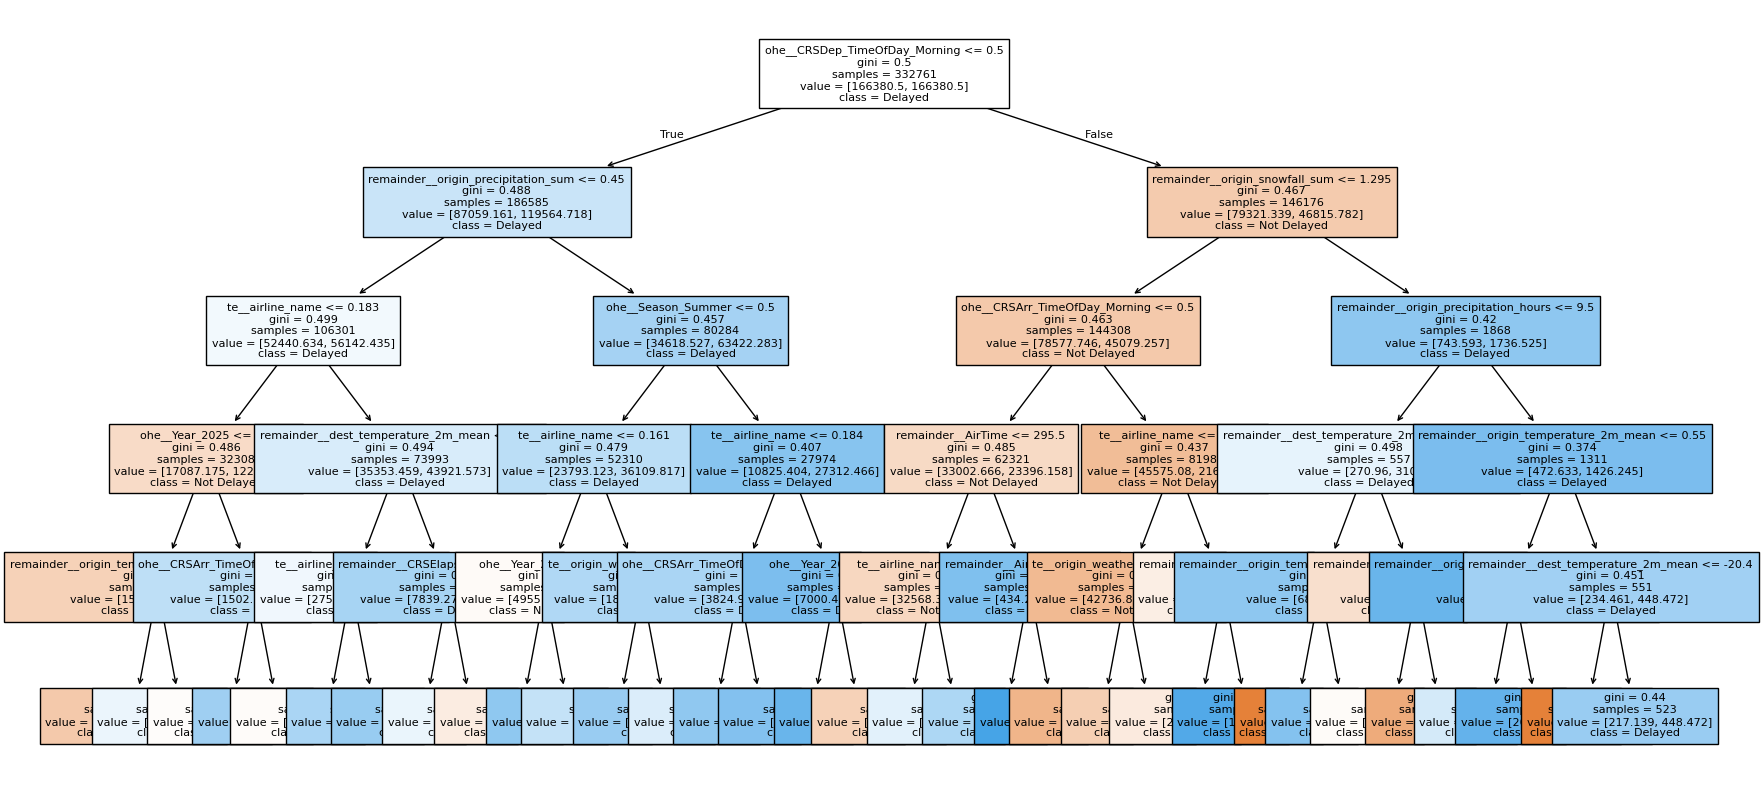

In [ ]:
from sklearn.tree import plot_tree

dt_model = dt_pipeline.named_steps["dt"]
plt.figure(figsize = (20,10))
plot_tree(dt_model, feature_names = dt_preprocessor.get_feature_names_out(), filled = True
            , class_names = ["Not Delayed", "Delayed"], fontsize = 8)
plt.show()

In [ ]:
pd.Series(dt_baseline_metrics).round(4)

train_accuracy     0.6791
train_recall       0.5409
train_precision    0.3082
train_f1           0.3927
train_roc_auc      0.6687
test_accuracy      0.6812
test_recall        0.5389
test_precision     0.3097
test_f1            0.3933
test_roc_auc       0.6687
dtype: float64

In [ ]:
# Set up preprocessing
rf_preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

# Build pipeline
rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("rf_clf", RandomForestClassifier(
        class_weight = "balanced",
        random_state = SEED
    ))
])

# Fit to X_train and y_train
rf_pipeline.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test)


In [ ]:
pd.Series(rf_metrics).round(4)

train_accuracy     0.9998
train_recall       0.9997
train_precision    0.9991
train_f1           0.9994
train_roc_auc      1.0000
test_accuracy      0.8124
test_recall        0.1796
test_precision     0.5323
test_f1            0.2686
test_roc_auc       0.7187
dtype: float64

In [ ]:
baseline = (y_test == 0).mean()
print(f"Baseline accuracy (predicting all non-delayed): {baseline:.4f}")

Baseline accuracy (predicting all non-delayed): 0.8082


In [ ]:
# Test a lower threhold for classifying a flight as delayed to see if we can improve recall
y_test_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]
threshold = 0.30
y_test_pred_threshold = (y_test_prob_rf >= threshold).astype(int)

def compute_metrics(y_true, y_pred, y_prob):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["recall"] = recall_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred)
    metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    return metrics

computed_metrics = compute_metrics(y_test, y_test_pred_threshold, y_test_prob_rf)
pd.Series(computed_metrics).round(4)

accuracy     0.7766
recall       0.4268
precision    0.4189
f1           0.4228
roc_auc      0.7187
dtype: float64

From the above metric table, we see our model is clearly overfitting. All of the training metrics are nearly perfect but our test_recall  is **significantly** lower than our baseline logistic regression. This is a clear sign that our model is over weighting non-delayed flights. The model overfitting is not too suprising, as we placed no restrictions on tree depth, minimum leaf samples, or minimum samples for a split.

Before moving on, we will take a look at what variables the Random Forest model flagged as most important.

In [ ]:
rf_model = rf_pipeline.named_steps["rf_clf"]
rf_preproc = rf_pipeline.named_steps["preprocessor"]
feature_names = rf_preproc.get_feature_names_out()
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending = False)

imp_df.head(10)

,Feature,Importance
19,remainder__AirTime,0.079795
18,remainder__CRSElapsedTime,0.069287
30,remainder__origin_temperature_2m_mean,0.056166
31,remainder__origin_wind_speed_10m_max,0.051955
37,remainder__origin_temperature_2m_range,0.051942
32,remainder__origin_wind_gusts_10m_max,0.050066
22,remainder__dest_temperature_2m_mean,0.044322
17,te__airline_name,0.041594
29,remainder__dest_temperature_2m_range,0.041435
24,remainder__dest_wind_gusts_10m_max,0.041309


We can see that the 10 most important variables ended up being mostly weather features. The most important variable was AirTime, which makes sense. CRSElapsedTime (estimated ElapsedTime) was also an important variable, which indicates that DOT's forecasting tools are quite good already.

## 5.3 XG Boost
The last model we will try is an XG Boost Classifier.

In [ ]:
# Set up preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

# Build pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb_clf", XGBClassifier(
        eval_metric = "logloss",
        scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum(),
        random_state = SEED
    ))
])

# Fit to X_train and y_train
pipeline.fit(X_train, y_train)

xgb_metrics = evaluate_model(pipeline, X_train, y_train, X_test, y_test)

In [ ]:
pd.Series(xgb_metrics).round(4)

train_accuracy     0.7332
train_recall       0.7009
train_precision    0.3909
train_f1           0.5019
train_roc_auc      0.7974
test_accuracy      0.7156
test_recall        0.6512
test_precision     0.3647
test_f1            0.4675
test_roc_auc       0.7559
dtype: float64

The XG Boost Classifier did the best out-of-the-box. It does slightly better than the weighted logistic regression across most metrics but is slightly worse on recall. We are once again stuck around 65%.

Now, we'll run a small randomized search to see if we can find hyperparameters that get us better recall scores. We are searching across values for `n_estimators` which sets the number of trees in the ensemble and `max_depth` which controls how complex each tree in the boosting sequence is. More trees could potentially improve the performance of the model with a higher risk of overfitting. The more complex each tree is, the more information they can learn but the higher the risk of them overfitting. By modulating these two hyperparameters, we hope to find a combination that strikes a strong balance between learning the data well but still being generalizable.

In [ ]:
# Set up preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

# Build pipeline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        eval_metric = "logloss",
        scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum(),
        random_state = SEED
    ))
])

# Parameter space
param_space = {
    "xgb__n_estimators": [100,200,300],
    "xgb__max_depth": [3,5,7]
}

param_space2 = {
    "xgb__n_estimators": [100, 200, 300, 500],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__subsample": [0.7, 0.85, 1.0],
    "xgb__colsample_bytree": [0.7, 0.85, 1.0]
    
    }

scoring = "average_precision"
# Initalize search
xgb_search = RandomizedSearchCV(
    pipeline,
    param_distributions = param_space2,
    n_iter = 9,
    scoring = scoring,
    cv = 5,
    n_jobs = -1,
    verbose = 2,
    random_state = SEED
)

# Fit to X_train and y_train
xgb_search.fit(X_train, y_train)# Display results
print(f"Best {scoring} (CV): {xgb_search.best_score_}")
print(f"Best hyperparameters: {xgb_search.best_params_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. Se

[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=  12.5s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=  12.5s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=  12.8s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=  12.3s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=  12.2s
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.1, xgb__max_depth=4, xgb__min_child_weight=5, xgb__n_estimators=100, xgb__subsample=1.0; total time=  10.1s
[CV] 

In [ ]:
# Display results
print(f"Best average_precision(CV): {xgb_search.best_score_}")
print(f"Best hyperparameters: {xgb_search.best_params_}")

Best average_precision(CV): 0.47264788286134196
Best hyperparameters: {'xgb__subsample': 0.85, 'xgb__n_estimators': 500, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.85}


In [ ]:
# Get all metrics for best pipeline
best_xgb_pipeline = xgb_search.best_estimator_

best_xgb_metrics = evaluate_model(best_xgb_pipeline, X_train, y_train, X_test, y_test)

pd.Series(best_xgb_metrics).round(4)

train_accuracy     0.7312
train_recall       0.6968
train_precision    0.3881
train_f1           0.4985
train_roc_auc      0.7942
test_accuracy      0.7162
test_recall        0.6533
test_precision     0.3657
test_f1            0.4689
test_roc_auc       0.7595
dtype: float64

train_accuracy     0.7474
train_recall       0.7189
train_precision    0.4096
train_f1           0.5218
train_roc_auc      0.8162
test_accuracy      0.7213
test_recall        0.6477
test_precision     0.3704
test_f1            0.4713
test_roc_auc       0.7588
dtype: float64

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_probs = cross_val_predict(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

rows = []
for t in thresholds:
    y_pred = (oof_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred, zero_division=0),
        "f1": f1_score(y_train, y_pred, zero_division=0),
        "n_alerts": y_pred.sum()
    })

threshold_df = pd.DataFrame(rows)

In [ ]:
threshold_df

,threshold,precision,recall,f1,n_alerts
0,0.05,0.191846,0.999906,0.321926,332585
1,0.10,0.193104,0.998574,0.323625,329978
2,0.15,0.198507,0.991679,0.330798,318779
3,0.20,0.209411,0.973014,0.344648,296493
4,0.25,0.225842,0.940637,0.364234,265774
5,0.30,0.247388,0.896789,0.387798,231317
6,0.35,0.272544,0.844165,0.412054,197645
7,0.40,0.299777,0.782780,0.433528,166624
8,0.45,0.329387,0.718042,0.451608,139104
9,0.50,0.362388,0.648274,0.464897,114151


In [ ]:
import numpy as np
import pandas as pd

def precision_at_k(model, X, y, k):
    """
    Compute Precision@k for a trained classifier.
    
    Parameters
    ----------
    model : fitted sklearn pipeline or model
    X : feature matrix
    y : true labels
    k : number of top predictions to evaluate
    
    Returns
    -------
    precision_at_k : float
    """

    # predicted probabilities for delay
def precision_at_k(model, X, y, k):
    probs = model.predict_proba(X)[:, 1]

    y_array = np.asarray(y)

    df = pd.DataFrame({
        "prob": probs,
        "actual": y_array
    })

    top_k = df.sort_values("prob", ascending=False).head(k)
    return top_k["actual"].mean()

In [ ]:
for k in [10, 20, 50, 100]:
    p_at_k = precision_at_k(best_xgb_pipeline, X_test, y_test, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 1.000
Precision@20: 1.000
Precision@50: 1.000
Precision@100: 1.000


Unfortunately our sparse search combined with the random nature of RandomizedSearchCV was not successful. In fact, the optimal model was slightly worse than our out-of-the-box model. This is, ultimately, the risk that randomized search poses, as there is always a chance of skipping over the optimal combo. Because of resource and time constraints, we chose to limit our search quite a bit. With enterprise resources, we could likely be more successful by casting a wider net for our search.

## 5.4 PCA Dimensionality Reduction
In order to lower the complexity of the data being fed into our models and to try and distill down the weather features in our data, we will implement PCA on both the origin and destination weather features.

We will run two PCA models, one for destination weather and one for origin_weather. That way, we can capture the variance across similar features and reduce down our overall feature space. The first step in applying PCA is to extract the relevant features from the training and testing sets.

In [ ]:
# PCA for origin and dest weather features
X_train_dest_weather = X_train[['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
       'dest_wind_gusts_10m_max', 'dest_precipitation_sum', 'dest_rain_sum',
       'dest_snowfall_sum', 'dest_precipitation_hours', 'dest_temperature_2m_range']]

X_test_dest_weather = X_test[['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
       'dest_wind_gusts_10m_max', 'dest_precipitation_sum', 'dest_rain_sum',
       'dest_snowfall_sum', 'dest_precipitation_hours', 'dest_temperature_2m_range']]

X_train_origin_weather = X_train[['origin_wind_speed_10m_max', 'origin_wind_gusts_10m_max',
       'origin_precipitation_sum', 'origin_rain_sum', 'origin_snowfall_sum',
       'origin_precipitation_hours', 'origin_temperature_2m_range']]

X_test_origin_weather = X_test[['origin_wind_speed_10m_max', 'origin_wind_gusts_10m_max',
       'origin_precipitation_sum', 'origin_rain_sum', 'origin_snowfall_sum',
       'origin_precipitation_hours', 'origin_temperature_2m_range']]


In [ ]:
# Initialize scalers
dest_scaler = StandardScaler()
origin_scaler = StandardScaler()

# Fit & transform scaler on training data
scaled_X_train_dest = dest_scaler.fit_transform(X_train_dest_weather)
scaled_X_train_origin = origin_scaler.fit_transform(X_train_origin_weather)

# Fit PCA on scaled train
dest_PCA = PCA()
origin_PCA = PCA()

dest_PCA.fit(scaled_X_train_dest)
origin_PCA.fit(scaled_X_train_origin)

PCA()

In [ ]:
# Initializing the explained_variance_ratios
dest_explained_variance_ratios = dest_PCA.explained_variance_ratio_
origin_explained_variance_ratios = origin_PCA.explained_variance_ratio_

# Calculating the cumulative sum
dest_cum_evr = np.cumsum(dest_explained_variance_ratios)
origin_cum_evr = np.cumsum(origin_explained_variance_ratios)

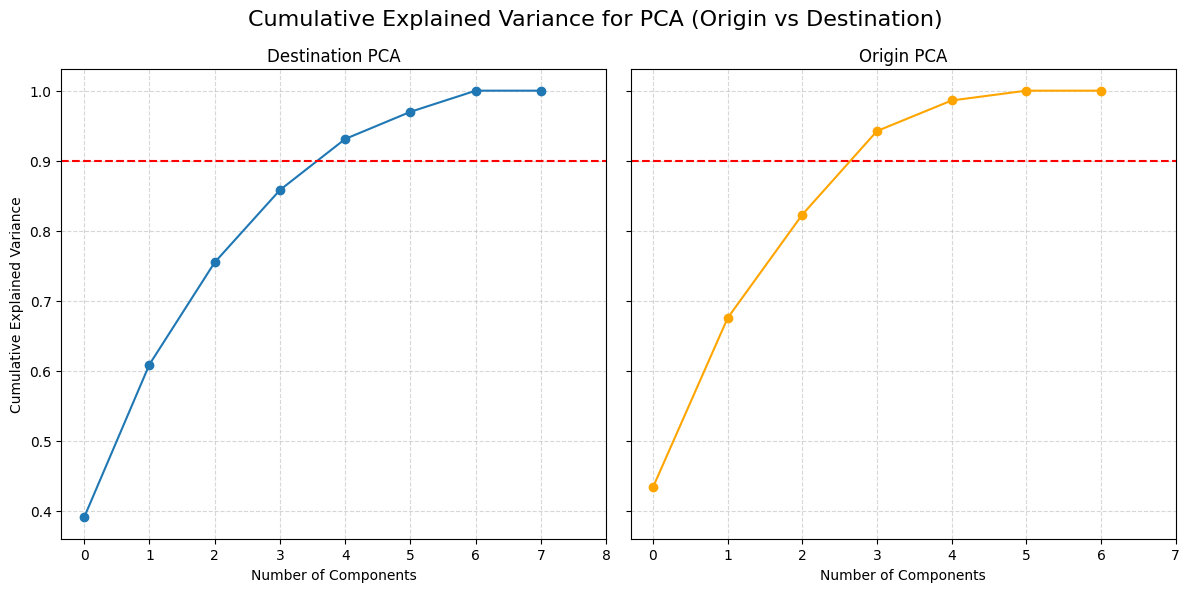

In [ ]:
# Create side-by-side plots
fig, axes = plt.subplots(ncols=2, figsize=(12,6), sharey=True)

# Destination PCA EVR
axes[0].plot(dest_cum_evr, marker='o')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Destination PCA')
axes[0].axhline(y=0.9, color='r', linestyle='--')
axes[0].set_xticks(np.arange(0, len(dest_explained_variance_ratios)+1, 1))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Origin PCA EVR
axes[1].plot(origin_cum_evr, marker='o', color='orange')
axes[1].set_xlabel('Number of Components')
axes[1].set_title('Origin PCA')
axes[1].axhline(y=0.9, color='r', linestyle='--')
axes[1].set_xticks(np.arange(0, len(origin_explained_variance_ratios)+1, 1))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Cumulative Explained Variance for PCA (Origin vs Destination)', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Create final PCA objects
final_dest_PCA = PCA(n_components = 4)
final_origin_PCA = PCA(n_components = 3)

# Fit transform on scaled training
PCA_X_train_dest = final_dest_PCA.fit_transform(scaled_X_train_dest)
PCA_X_train_origin = final_origin_PCA.fit_transform(scaled_X_train_origin)

PCA_X_train_dest_df = pd.DataFrame(PCA_X_train_dest,
                           columns=[f"dest_PC{i+1}" for i in range(PCA_X_train_dest.shape[1])])

PCA_X_train_origin_df = pd.DataFrame(PCA_X_train_origin,
                             columns=[f"origin_PC{i+1}" for i in range(PCA_X_train_origin.shape[1])])

# Use fitted scaler to transform test sets
scaled_X_test_dest = dest_scaler.transform(X_test_dest_weather)
scaled_X_test_origin = origin_scaler.transform(X_test_origin_weather)

# Run fitted PCA on scaled test sets
PCA_X_test_dest = final_dest_PCA.transform(scaled_X_test_dest)
PCA_X_test_origin = final_origin_PCA.transform(scaled_X_test_origin)

PCA_X_test_dest_df = pd.DataFrame(PCA_X_test_dest,
                           columns=[f"dest_PC{i+1}" for i in range(PCA_X_test_dest.shape[1])])

PCA_X_test_origin_df = pd.DataFrame(PCA_X_test_origin,
                             columns=[f"origin_PC{i+1}" for i in range(PCA_X_test_origin.shape[1])])

# Reconstruct X_train, X_test with PCA features
X_train_no_weather = X_train.drop(columns = ['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
                                             'dest_wind_gusts_10m_max', 'dest_precipitation_sum',
                                             'dest_rain_sum', 'dest_snowfall_sum', 'dest_precipitation_hours',
                                             'dest_temperature_2m_range', 'origin_wind_speed_10m_max',
                                             'origin_wind_gusts_10m_max','origin_precipitation_sum',
                                             'origin_rain_sum', 'origin_snowfall_sum','origin_precipitation_hours',
                                             'origin_temperature_2m_range'])

X_test_no_weather = X_test.drop(columns = ['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
                                             'dest_wind_gusts_10m_max', 'dest_precipitation_sum',
                                             'dest_rain_sum', 'dest_snowfall_sum', 'dest_precipitation_hours',
                                             'dest_temperature_2m_range', 'origin_wind_speed_10m_max',
                                             'origin_wind_gusts_10m_max','origin_precipitation_sum',
                                             'origin_rain_sum', 'origin_snowfall_sum','origin_precipitation_hours',
                                             'origin_temperature_2m_range'])

X_train_PCA = pd.concat([
    X_train_no_weather.reset_index(drop=True),
    PCA_X_train_dest_df.reset_index(drop=True),
    PCA_X_train_origin_df.reset_index(drop=True)],
                        axis = 1)
X_test_PCA = pd.concat([X_test_no_weather.reset_index(drop=True),
                        PCA_X_test_dest_df.reset_index(drop=True),
                        PCA_X_test_origin_df.reset_index(drop=True)],
                       axis = 1)

## 5.5 PCA + Weighted Logistic Regression

Now, we will use our newly created reduced training data to train another weighted logistic regression model. We chose weighted logistic regression because it had the best recall performance out of the 3 models we tested.

We will need to adjust our pipeline slightly to avoid double standardizing our principal components, but otherwise, the process should look quite similar to 5.1.

In [ ]:
# Create list of numeric columns (other than principal components)
non_pca_numeric_cols = ["CRSElapsedTime", "AirTime", "Distance",
                        "SinMonth", "CosMonth", "SinDay", "CosDay"]

In [ ]:
# Set up preprocessing
pc_preprocessor = ColumnTransformer(
    transformers = [
        ("scale_numeric", StandardScaler(), non_pca_numeric_cols),
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ]
)

# Build pipeline
pc_pipeline = Pipeline([
    ("preprocessor", pc_preprocessor),
    ("weighted_lrg", LogisticRegression(
        max_iter = 2000,
        class_weight = "balanced"
    ))
])

# Fit to X_train and y_train
X_train_PCA = X_train_PCA.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test_PCA = X_test_PCA.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

pc_pipeline.fit(X_train_PCA, y_train)

pc_weighted_lrg_baseline_metrics = evaluate_model(pc_pipeline, X_train_PCA, y_train, X_test_PCA, y_test)

In [ ]:
pd.Series(pc_weighted_lrg_baseline_metrics).round(4)

,0
train_accuracy,0.6460
train_recall,0.6607
train_precision,0.3048
train_f1,0.4171
train_roc_auc,0.7047
test_accuracy,0.6462
test_recall,0.6599
test_precision,0.3049
test_f1,0.4170
test_roc_auc,0.7055


Unfortunately we do not see much improvement at all in our recall score. This could be a sign that our data is a bottleneck in how good of a model we can make at this point.

In [ ]:
pc_lrg_preproc = lrg_pipeline.named_steps["preprocessor"]
pc_lrg_model = lrg_pipeline.named_steps["weighted_lrg"]

feature_names = pc_lrg_preproc.get_feature_names_out()
coefs = pc_lrg_model.coef_.flatten()

pc_coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

pc_coef_df.head(10)

,feature,coef,abs_coef
40,te__airline_name,5.240671,5.240671
37,te__Origin,2.663257,2.663257
1,scale_numeric__AirTime,2.044783,2.044783
0,scale_numeric__CRSElapsedTime,-1.883558,1.883558
27,ohe__Year_2025,1.063532,1.063532
26,ohe__Year_2024,0.934212,0.934212
25,ohe__Year_2023,0.799254,0.799254
24,ohe__Year_2022,0.762428,0.762428
23,ohe__Year_2021,0.555273,0.555273
29,ohe__Season_Summer,0.476703,0.476703


Again we see the same variables as our baseline model showing up as important. It appears that our principal components are not playing a very big role in predicting flight delays.

# Part 6: Conclusion

**In summary, here are the main takeaways:**

1. Daily aggregated weather may not be granular enough to really inform flight delay prediction.
2. CHA is a particularly problematic airport when it comes to delayed flights. Airport administrators can take that into account when deciding where to place gates for those flights.
3. Our best model was the weighted logistic regression with a recall of 66%. Unfortunatley a recall of 66% is not nearly good enough for use in a fast-paced enterprise setting like PHL. The lack of effective models leads us to believe that the underlying data was not sufficient to tackle this problem.
4. The only consistently important variables across our models was airline name, CRS Elapsed Time, and Air Time. It was interesting to see the random forest flag several weather variables as important while the logistic regression did not. That fact supports our initial thought that weather had a non-linear relationship with flight delays.

Ultimately, none of the models were performant enough to be deployable at PHL. However, the analysis did lend a unique insight into the importance of granular data in flight delay prediction. In particular the daily weather variables we expected to be quite useful turned out to be far too broad to provide any meaningful insight.

**In the future, it would be interesting to consider implementing the following modifications:**

1.   Joining with more datasets to increase the complexity of the model and to provide richer information about flight delays.
2. Leveraging more resources to get more granular weather data, including hourly weather data from the flight's actual path.
3. Brining in airport specific data like FAA staffing levels or exogenous local events that might be signals for sudden upticks in traffic.
4. Attempting regression rather than classification for predicting the actual amount of time a flight will be delayed to allow for more granular thresholding and operational flexibility.

**Overall Experience + Team Reflection:**

This project was a great exercise in going through the entire data science life cycle. In particular, we have a much better understanding of how hard it is to get really good data for a problem. This project has really re-enforced the idea that data science is not about building flashy models but about sifting through bad data to find something that might actually work for your problem. Overall, this project was a challenging but worthwhile experience that gave us a strong overview of data science.


